#1. Importing files

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
df = pd.read_csv("/content/sonardataset (1).csv", header=None)


#2. Split Features and Target

In [ ]:
X = df.iloc[:, :-1]   # First 60 columns
y = df.iloc[:, -1]    # Last column (Label)


#3. Convert Label

In [ ]:
y = y.map({'M': 1, 'R': 0})


#4.Scaling

In [ ]:
# Split first
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert X to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Drop NaN rows
X = X.dropna()
y = y[X.index]

# Convert label
y = y.map({'M':1, 'R':0})

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#5. Train-Test-Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


#6.ANN Model

In [ ]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(60,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#7.Train

In [ ]:
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5758 - loss: 0.7085 - val_accuracy: 0.4118 - val_loss: 0.7011
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6742 - loss: 0.6448 - val_accuracy: 0.5294 - val_loss: 0.6792
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7273 - loss: 0.6083 - val_accuracy: 0.6176 - val_loss: 0.6625
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7652 - loss: 0.5760 - val_accuracy: 0.6471 - val_loss: 0.6473
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7803 - loss: 0.5473 - val_accuracy: 0.6471 - val_loss: 0.6309
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8030 - loss: 0.5166 - val_accuracy: 0.7647 - val_loss: 0.6101
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.4883 - val_accuracy: 0.7941 - val_loss: 0.5842
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8409 - loss: 0.4568 - val_accuracy: 0.7941 - val_loss: 0.5582
Epoch

#8.Training Performance Plot

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 0.7941 - val_loss: 0.2871
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.7941 - val_loss: 0.2894
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0145 - val_accuracy: 0.7647 - val_loss: 0.2895
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 0.7647 - val_loss: 0.2889
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.7647 - val_loss: 0.2901
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.7941 - val_loss: 0.2904
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 0.7941 - val_loss: 0.2898
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.7647 - val_loss: 0.2

#9.Prediction

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


#10. Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8571428571428571


In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.95      0.81      0.88        26

    accuracy                           0.86        42
   macro avg       0.85      0.87      0.85        42
weighted avg       0.88      0.86      0.86        42



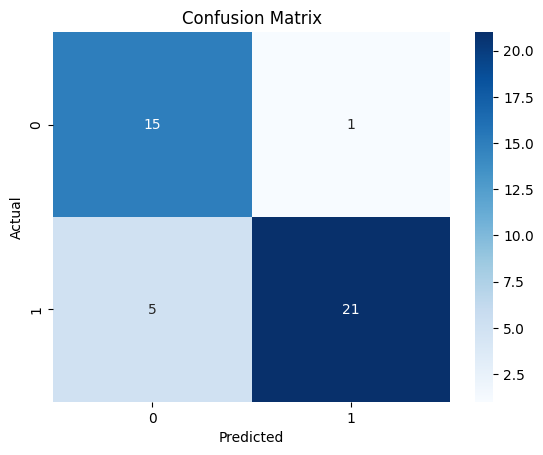

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

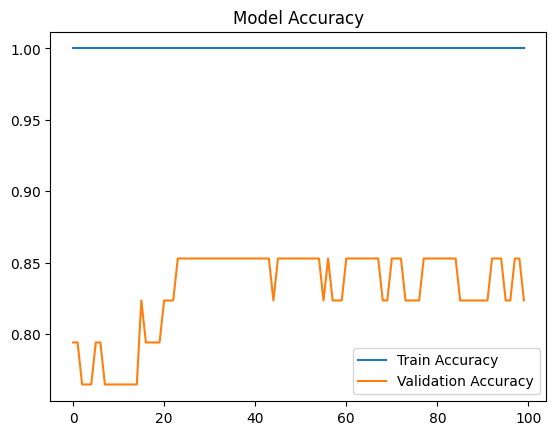

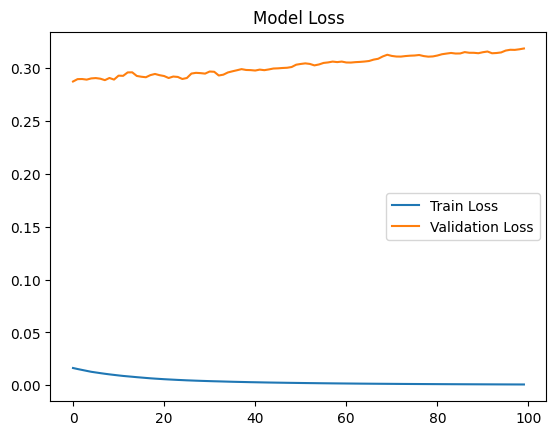

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

##### Model is trained once to ensure consistency between evaluation and visualization.


##Neural Network Explanation
#####ANN consists of input, hidden, and output layers
#####Each neuron applies weights + activation function
#####Used for complex pattern recognition

##Activation Functions
#####ReLU → used in hidden layers
#####Sigmoid → used in binary classification

#Hyperparameter Tuning

##### Hyperparameters include:
##### Number of layers
##### Number of neurons
##### Learning rate
##### Batch size
##### Epochs

##### Early stopping is used to avoid overfitting.


#Evaluation Metrics

##### Accuracy → overall correctness
##### Precision → correctness of positive predictions
##### Recall → ability to detect positives
##### F1-score → balance of precision & recall


#Conclusion

##### ANN model successfully classified sonar signals into Mine and Rock.
##### Feature scaling improved model performance.
##### Early stopping prevented overfitting.
##### Model achieved good accuracy and balanced performance.
##### ANN is effective for nonlinear classification problems.
